In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
import jax
import jax.numpy as jnp
import inspeqtor as sq
import matplotlib.pyplot as plt


key = jax.random.key(0)

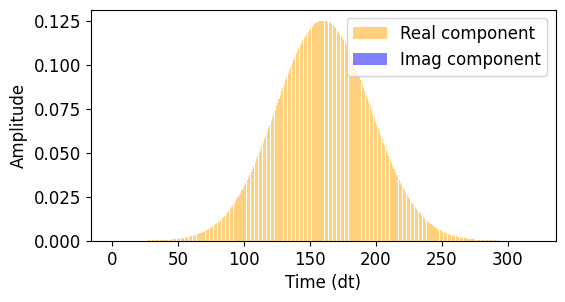

In [3]:
qubit_info = sq.data.QubitInformation(
    unit="GHz",
    qubit_idx=0,
    anharmonicity=-0.2,
    frequency=5.0,
    drive_strength=0.1,
)

total_length = 320
dt = 2 / 9
pulse = sq.control.library.DragPulseV2(
    duration=total_length,
    qubit_drive_strength=qubit_info.drive_strength,
    dt=2 / 9,
    max_amp=0.5,
    min_theta=0,
    max_theta=2 * jnp.pi,
    min_beta=-5.0,
    max_beta=5.0,
)

control_sequence = sq.control.ControlSequence(
    controls={"drag": pulse},
    total_dt=total_length,
)


fig, ax = plt.subplots(figsize=(6, 3))

t_eval = jnp.linspace(0, total_length, total_length)

params = {
    "drag": {
        "theta": 0.5 * jnp.pi,
        "beta": 0.0,
    }
}
waveform = sq.control.sequence_waveform(params, t_eval, control_sequence)

sq.utils.plot_control_envelope(waveform, t_eval, ax)

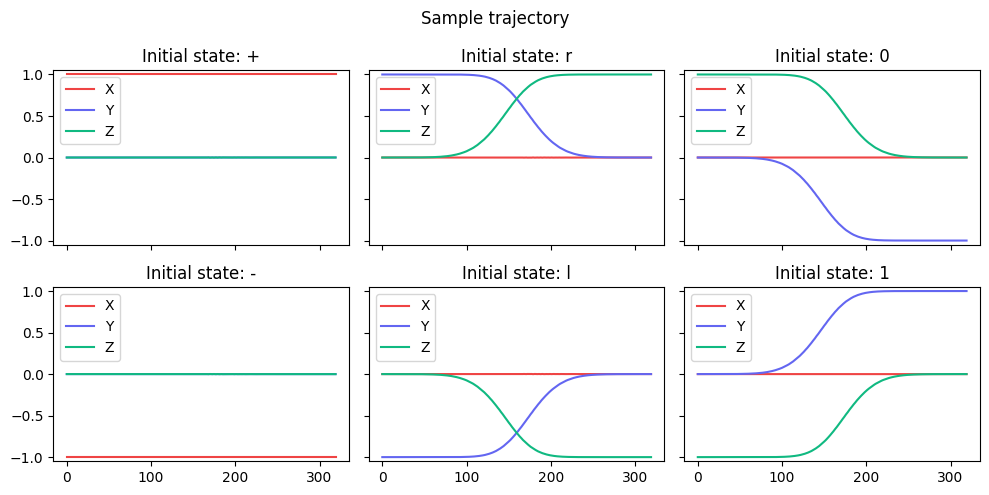

In [4]:
from functools import partial

signal_fn = sq.physics.make_signal_fn(
    get_envelope=control_sequence.get_envelope,
    drive_frequency=qubit_info.frequency,
    dt=dt,
)

hamiltonian = partial(
    sq.physics.library.transmon_hamiltonian, qubit_info=qubit_info, signal=signal_fn
)
frame = (jnp.pi * qubit_info.frequency) * sq.utils.Z
hamiltonian = sq.physics.auto_rotating_frame_hamiltonian(hamiltonian, frame=frame)

solver = partial(
    sq.physics.solver,
    t_eval=t_eval * dt,  # nanosecond.
    hamiltonian=hamiltonian,
    y0=jnp.eye(2, dtype=jnp.complex_),
    t0=0.0,  # nanosecond.
    t1=total_length * dt,  # nanosecond.
)

unitary = solver(params)

fig, axes = sq.utils.plot_expectation_values(
    sq.utils.dictorization(
        sq.utils.calculate_expectation_values(unitary).T,
        order=sq.utils.get_default_expectation_values_order(),
    ),
    title="Sample trajectory",
)

## Dispersive qubit readout


In the followings, we will learn how to use `inspeqtor` to simulate the dispersive readout of a qubit [^1]. We will start by defining the system parameters and then we will simulate the measurement process.

[^1]: https://arxiv.org/pdf/2005.12667

In [5]:
from diffrax import diffeqsolve, ODETerm, Tsit5, SaveAt

chi = 2.0 * jnp.pi * 1.0  # Dispersive shift (MHz)
noise_scale = 0.5  # Amplifier noise level


@jax.jit
def langevin_solver(
    params: dict, readout: jnp.ndarray
) -> jnp.ndarray:

    t_max, delta_d, epsilon = params["t_max"], params["delta_d"], params["epsilon"]

    def drift(t, alpha, args):
        kappa = 2.0 * jnp.pi * 5.0  # Resonator linewidth (MHz)

        delta_q = jnp.where(readout == 0, delta_d + chi, delta_d - chi)

        return -1j * delta_q * alpha - (kappa / 2) * alpha - 1j * epsilon

    term = ODETerm(drift)
    solver = Tsit5()
    t0, t1 = 0.0, t_max
    dt0 = 0.01

    sol = diffeqsolve(
        term,
        solver,
        t0=t0,
        t1=t1,
        dt0=dt0,
        y0=0j + 0.0,
        saveat=SaveAt(ts=jnp.linspace(t0, t1, 100)),
    )

    solutions = sol.ys
    assert solutions is not None, "ODE solver failed to produce a solution."
    return solutions

def basic_classifier(iq_readout: jnp.ndarray) -> jnp.ndarray:
    return (iq_readout.real > 0).astype(int)

In [6]:
shots = 1000
# Calculate the density matrix after the control pulse
density_matrix = unitary[-1] @ sq.data.get_initial_state("0") @ unitary[-1].conj().T
# Calculate the probability of measuring "0" state.
prob_0 = jnp.trace(density_matrix @ sq.data.get_initial_state("0"))
# Simulate the measurement outcome based on the calculated probabilities.
key, subkey = jax.random.split(key)
intermediate_readout = jax.random.choice(
    subkey, a=jnp.array([0, 1]), p=jnp.array([prob_0.real, 1 - prob_0.real]), shape=(shots, )
)

# Define measurement parameters and simulate the IQ readout for each shot, adding noise to mimic realistic measurement conditions.
params = {
    "t_max": jnp.array(1.0),  # Integration time (microseconds)
    "delta_d": jnp.array(0.0),  # Drive detuning from resonator center
    "epsilon": jnp.array(2.0 * jnp.pi * 10.0),  # Drive amplitude
}

i_key, q_key = jax.random.split(key)

# iq_trajectory = jax.vmap(langevin_solver, in_axes=(None, 0))(params, intermediate_readout)
iq_trajectory_0 = langevin_solver(params, jnp.array(0))
iq_trajectory_1 = langevin_solver(params, jnp.array(1))
# Use jnp.where to select the appropriate trajectory based on the intermediate readout for each shot.
iq_trajectory = jnp.where(intermediate_readout[:, None] == 0, iq_trajectory_0, iq_trajectory_1)

# The final IQ readout is the last point of the trajectory plus some noise to simulate the measurement process.
iq_readout = iq_trajectory[:, -1] + noise_scale * (
    jax.random.normal(i_key, shape=(shots,))
    + 1j * jax.random.normal(q_key, shape=(shots,))
)

Number of shots classified as '0': 488
Number of shots classified as '1': 512


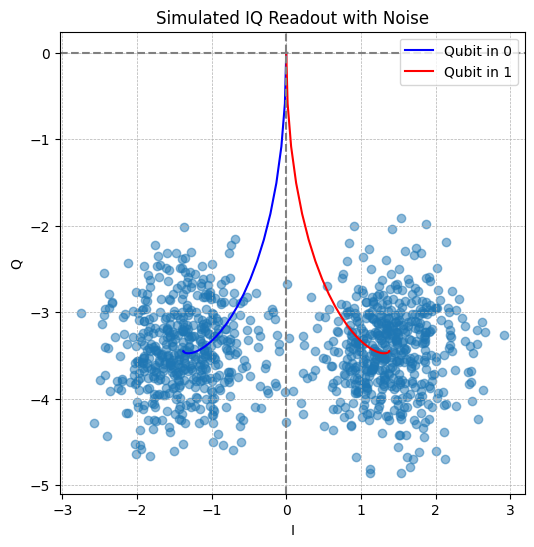

In [7]:
basic_classification = basic_classifier(iq_readout)
counts = jnp.bincount(basic_classification, minlength=2)
print(f"Number of shots classified as '0': {counts[0]}")
print(f"Number of shots classified as '1': {counts[1]}")

fig, ax = plt.subplots(figsize=(6, 6))
# Plot the IQ readout points, where the real part corresponds to the I quadrature and the imaginary part corresponds to the Q quadrature.
ax.scatter(iq_readout.real, iq_readout.imag, alpha=0.5)
# Plot the trajectory of the IQ readout for both 0 and 1 states, showing how the resonator state evolves over time during the measurement process.
ax.plot(iq_trajectory_0.real, iq_trajectory_0.imag, label="Qubit in 0", color="blue")
ax.plot(iq_trajectory_1.real, iq_trajectory_1.imag, label="Qubit in 1", color="red")

ax.legend()

ax.set_xlabel("I")
ax.set_ylabel("Q")
ax.set_title("Simulated IQ Readout with Noise")
plt.axvline(0, color="gray", linestyle="dashed")
plt.axhline(0, color="gray", linestyle="dashed")
plt.grid(True, which="both", linestyle="dashed", linewidth=0.5)
plt.show()

Number of shots classified as '0': 806
Number of shots classified as '1': 194


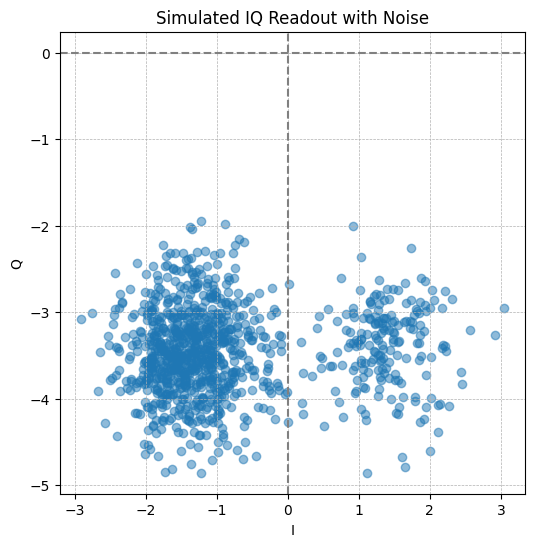

In [9]:
@jax.jit
def langevin_solver_with_t1(
    params: dict, readout: jnp.ndarray, key: jnp.ndarray, T1: float = jnp.inf
) -> jnp.ndarray:

    t_max, delta_d, epsilon = params["t_max"], params["delta_d"], params["epsilon"]

    # Sample the exact moment of decay
    decay_time = -jnp.log(jax.random.uniform(key, minval=1e-6)) * T1

    def drift(t, alpha, args):
        kappa = 2.0 * jnp.pi * 5.0  # Resonator linewidth (MHz)

        current_state = jnp.where((readout == 1) & (t < decay_time), 1, 0)
        delta_q = jnp.where(current_state == 0, delta_d + chi, delta_d - chi)

        return -1j * delta_q * alpha - (kappa / 2) * alpha - 1j * epsilon

    term = ODETerm(drift)
    solver = Tsit5()
    t0, t1 = 0.0, t_max
    dt0 = 0.01

    sol = diffeqsolve(
        term,
        solver,
        t0=t0,
        t1=t1,
        dt0=dt0,
        y0=0j + 0.0,
        saveat=SaveAt(ts=jnp.linspace(t0, t1, 100)),
    )

    solutions = sol.ys
    assert solutions is not None, "ODE solver failed to produce a solution."
    return solutions


keys = jax.random.split(key, shots)
iq_readout_raw = jax.vmap(langevin_solver_with_t1, in_axes=(None, 0, 0, None))(
    params, intermediate_readout, keys, 1.0
)

iq_readout = iq_readout_raw[:, -1] + noise_scale * (
    jax.random.normal(i_key, shape=(shots,))
    + 1j * jax.random.normal(q_key, shape=(shots,))
)

basic_classification = basic_classifier(iq_readout)
counts = jnp.bincount(basic_classification, minlength=2)
print(f"Number of shots classified as '0': {counts[0]}")
print(f"Number of shots classified as '1': {counts[1]}")

fig, ax = plt.subplots(figsize=(6, 6))
# Plot the IQ readout points, where the real part corresponds to the I quadrature and the imaginary part corresponds to the Q quadrature.
ax.scatter(iq_readout.real, iq_readout.imag, alpha=0.5)

ax.set_xlabel("I")
ax.set_ylabel("Q")
ax.set_title("Simulated IQ Readout with Noise")
plt.axvline(0, color="gray", linestyle="dashed")
plt.axhline(0, color="gray", linestyle="dashed")
plt.grid(True, which="both", linestyle="dashed", linewidth=0.5)
plt.show()